In [1]:

# Standard library
import kagglehub
import os
import gc
import json
import time
import warnings
import random
from pathlib import Path
import shutil

# Numerical computing and data processing
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

# Scikit-learn
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from scipy.stats import chi2_contingency, fisher_exact

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, TensorDataset
from torchvision import datasets, models, transforms
from torchvision.models import ResNet50_Weights
from collections import Counter
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

from tqdm import tqdm

# Suppress warnings
warnings.filterwarnings('ignore')


# Table of Contents
[Table of Contents](#scrollTo=hLFT2mh4pZa0)

>[Baseline CNN](#scrollTo=m_K5LOwTqREv)

>>[Performance Monitoring](#scrollTo=sGSQj2_Gu8sw)

>[Gender Bias Analysis](#scrollTo=4ZBrquU2qohU)
---

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [20]:
adults_cache = Path("/content/drive/MyDrive/fer-project/fer2013_processed/fer2013_adults.pt")

# Load JSON regardless — needed for label_strs and genders even on cache hit
with open("/content/drive/MyDrive/fer-project/fer2013_processed/classified_files.json") as f:
    loaded_data = json.load(f)

records    = loaded_data["adult_records"]
label_strs = [r["emotion"] for r in records]
genders    = [r["gender"]  for r in records]
label_names  = sorted(set(label_strs))
label_to_idx = {l: i for i, l in enumerate(label_names)}

if adults_cache.exists():
    print("Loading from cache...")
    d = torch.load(adults_cache, weights_only=False)
    X = d["X"].numpy()
    X_CNN = d["X_CNN"].numpy()
    y = d["y"].numpy()
    paths = d["paths"]
    print(f"Loaded from cache: {len(paths)} images")
else:
    print("Cache not found — loading from Drive (this will take ~30-60 min)...")
    paths = [Path(r["drive_path"]) for r in records]

    base_transform = transforms.Compose([
        transforms.Resize((48, 48)),
        transforms.ToTensor(),
    ])
    cnn_transform = transforms.Normalize(mean=[0.5], std=[0.5])

    X_tensors = torch.stack([base_transform(Image.open(p).convert("L")) for p in tqdm(paths)])
    X  = X_tensors.view(X_tensors.shape[0], -1)
    X_CNN     = torch.stack([cnn_transform(t) for t in X_tensors])
    y         = torch.tensor([label_to_idx[e] for e in label_strs], dtype=torch.long)

    # Save cache to Drive — future runs will skip all of the above
    torch.save({"X": X, "X_CNN": X_CNN, "y": y, "paths": paths}, adults_cache)
    print(f"Cache saved: {adults_cache}")

    X = X.numpy()
    X_CNN = X_CNN.numpy()
    y = y.numpy()

print(f"Adults-only subset loaded: {len(paths)} images (full dataset had ~35,887).")
print("Flattened data shape (X):", X.shape)
print("CNN data shape (X_CNN):", X_CNN.shape)
print("Labels:", label_names)

Cache not found — loading from Drive (this will take ~30-60 min)...


100%|██████████| 25175/25175 [1:40:42<00:00,  4.17it/s]


Cache saved: /content/drive/MyDrive/fer-project/fer2013_processed/fer2013_adults.pt
Adults-only subset loaded: 25175 images (full dataset had ~35,887).
Flattened data shape (X): (25175, 2304)
CNN data shape (X_CNN): (25175, 1, 48, 48)
Labels: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Baseline CNN

Our immediate next steps are to first build and train a baseline CNN, then integrate the data augmentation pipeline into the training loop. Class weight loss is also added to address class imbalance. We  evaluate the model using metrics such as accuracy, confusion matrices, and per-class F1 scores.

The baseline CNN below is trained on the **cleaned adults-only subset** produced in the EDA (via the CLIP filtering pass), *not* on the raw Kaggle FER-2013 dump. This removes babies, cartoons, and blank/near-black images that otherwise inject label noise, so the model is learning the emotion signal on realistic adult faces only.

In [21]:
class BaselineCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        self.dropout = nn.Dropout(0.5)
        self.fc1 = nn.Linear(128 * 6 * 6, 256)
        self.fc2 = nn.Linear(256, num_classes)
    def forward(self, x):
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        x = self.pool(F.relu(self.bn2(self.conv2(x))))
        x = self.pool(F.relu(self.bn3(self.conv3(x))))
        x = x.view(-1, 128 * 6 * 6)
        x = self.dropout(F.relu(self.fc1(x)))
        return self.fc2(x)

In [22]:

# Split Data
idx = np.arange(len(X_CNN))
y_np = y

idx_train, idx_temp = train_test_split(idx, test_size=0.20, stratify=y_np, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.5, stratify=y_np[idx_temp], random_state=42)

# Convert NumPy arrays back to PyTorch tensors before sending to the GPU
X_train = torch.tensor(X_CNN[idx_train]).to(device)
y_train = torch.tensor(y[idx_train], dtype=torch.long).to(device)

X_val = torch.tensor(X_CNN[idx_val]).to(device)
y_val = torch.tensor(y[idx_val], dtype=torch.long).to(device)

X_test = torch.tensor(X_CNN[idx_test]).to(device)
y_test = torch.tensor(y[idx_test], dtype=torch.long).to(device)

# Create DataLoaders
BATCH_SIZE = 64
all_preds = []
all_targets = []
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=BATCH_SIZE)

In [ ]:
# Training augmentation
train_transform = transforms.Compose([
    transforms.RandomRotation(degrees=15),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1), shear=5),
])

In [ ]:

# Training Functions
def train_model(model, train_loader, criterion, optimizer, device, augment_transform):
    model.train()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        # Apply data augmentation only to training data
        if augment_transform is not None:
            inputs = augment_transform(inputs)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * inputs.size(0)
        _, predicted = torch.max(outputs.data, 1)
        total_samples += labels.size(0)
        correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.inference_mode():
        for inputs, labels in data_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total_samples += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples
    return epoch_loss, epoch_acc

In [ ]:
# class-weighted loss
train_counts = Counter(y[idx_train].tolist())        # count per class in train split
class_counts = np.array(
    [train_counts[i] for i in range(len(label_names))],
    dtype=np.float32
)
class_weights = class_counts.sum() / (len(class_counts) * class_counts)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
print('Class weights:', dict(zip(label_names, class_weights.round(3))))

Class weights: {'angry': np.float32(0.984), 'disgust': np.float32(7.714), 'fear': np.float32(0.965), 'happy': np.float32(0.541), 'neutral': np.float32(0.811), 'sad': np.float32(0.889), 'surprise': np.float32(1.636)}


In [ ]:
num_classes = len(label_names)
model = BaselineCNN(len(label_names)).to(device)
compiled_model = torch.compile(model)

# Reinitialize the optimizer
optimizer = optim.Adam(compiled_model.parameters(), lr=0.001, weight_decay=1e-4)

num_epochs = 50
history_aug = {
    'train_loss_aug': [], 'train_acc_aug': [],
    'val_loss_aug': [], 'val_acc_aug': []
}
best_val_acc = 0

for epoch in range(num_epochs):
    train_loss_aug, train_acc_aug = train_model(
        compiled_model,
        train_loader,
        criterion,
        optimizer,
        device,
        augment_transform=train_transform,
    )
    val_loss_aug, val_acc_aug = evaluate_model(compiled_model, val_loader, criterion, device)

    if val_acc_aug > best_val_acc:
        best_val_acc = val_acc_aug
        torch.save(compiled_model.state_dict(), 'best_model_cnn_aug.pth')

    history_aug['train_loss_aug'].append(train_loss_aug)
    history_aug['train_acc_aug'].append(train_acc_aug)
    history_aug['val_loss_aug'].append(val_loss_aug)
    history_aug['val_acc_aug'].append(val_acc_aug)

    print(f'Epoch {epoch+1}/{num_epochs} - '
          f'Train Loss: {train_loss_aug:.4f}, Train Acc: {train_acc_aug:.4f} - '
          f'Val Loss: {val_loss_aug:.4f}, Val Acc: {val_acc_aug:.4f}')

print("Training with Augmentation complete!")
shutil.copy('best_model_cnn_aug.pth', '/content/drive/MyDrive/fer-project/fer2013_processed/best_model_cnn_aug.pth')

Epoch 1/50 - Train Loss: 1.9663, Train Acc: 0.1700 - Val Loss: 1.8870, Val Acc: 0.2253
Epoch 2/50 - Train Loss: 1.8915, Train Acc: 0.2184 - Val Loss: 1.8977, Val Acc: 0.2237
Epoch 3/50 - Train Loss: 1.8604, Train Acc: 0.2346 - Val Loss: 1.7665, Val Acc: 0.2618
Epoch 4/50 - Train Loss: 1.8434, Train Acc: 0.2355 - Val Loss: 1.7354, Val Acc: 0.2932
Epoch 5/50 - Train Loss: 1.8158, Train Acc: 0.2282 - Val Loss: 1.7060, Val Acc: 0.2050
Epoch 6/50 - Train Loss: 1.7973, Train Acc: 0.2615 - Val Loss: 1.6760, Val Acc: 0.3611
Epoch 7/50 - Train Loss: 1.8036, Train Acc: 0.2628 - Val Loss: 1.6500, Val Acc: 0.3822
Epoch 8/50 - Train Loss: 1.7750, Train Acc: 0.2836 - Val Loss: 1.6274, Val Acc: 0.3671
Epoch 9/50 - Train Loss: 1.7716, Train Acc: 0.2846 - Val Loss: 1.6007, Val Acc: 0.3731
Epoch 10/50 - Train Loss: 1.7544, Train Acc: 0.2954 - Val Loss: 1.5776, Val Acc: 0.4124
Epoch 11/50 - Train Loss: 1.7458, Train Acc: 0.3066 - Val Loss: 1.5914, Val Acc: 0.3814
Epoch 12/50 - Train Loss: 1.7445, Train A

### Performance Monitoring
We track the loss/accuracy at every epoch. We evaluate the model using metrics such as accuracy, confusion matrix, and per-class F1 scores.

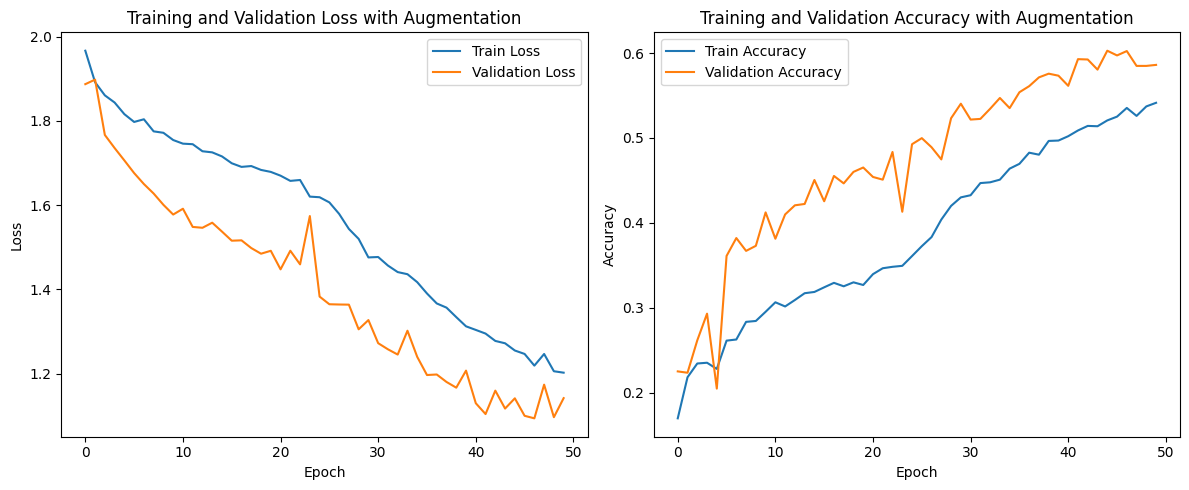

In [ ]:
# Plotting training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history_aug['train_loss_aug'], label='Train Loss')
plt.plot(history_aug['val_loss_aug'], label='Validation Loss')
plt.title('Training and Validation Loss with Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Plotting training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(history_aug['train_acc_aug'], label='Train Accuracy')
plt.plot(history_aug['val_acc_aug'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy with Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()


Classification Report:
              precision    recall  f1-score   support

       angry       0.66      0.27      0.38       365
     disgust       0.33      0.74      0.46        46
        fear       0.44      0.27      0.34       373
       happy       0.81      0.86      0.84       665
     neutral       0.58      0.61      0.59       444
         sad       0.43      0.53      0.48       405
    surprise       0.51      0.85      0.64       220

    accuracy                           0.59      2518
   macro avg       0.54      0.59      0.53      2518
weighted avg       0.60      0.59      0.57      2518



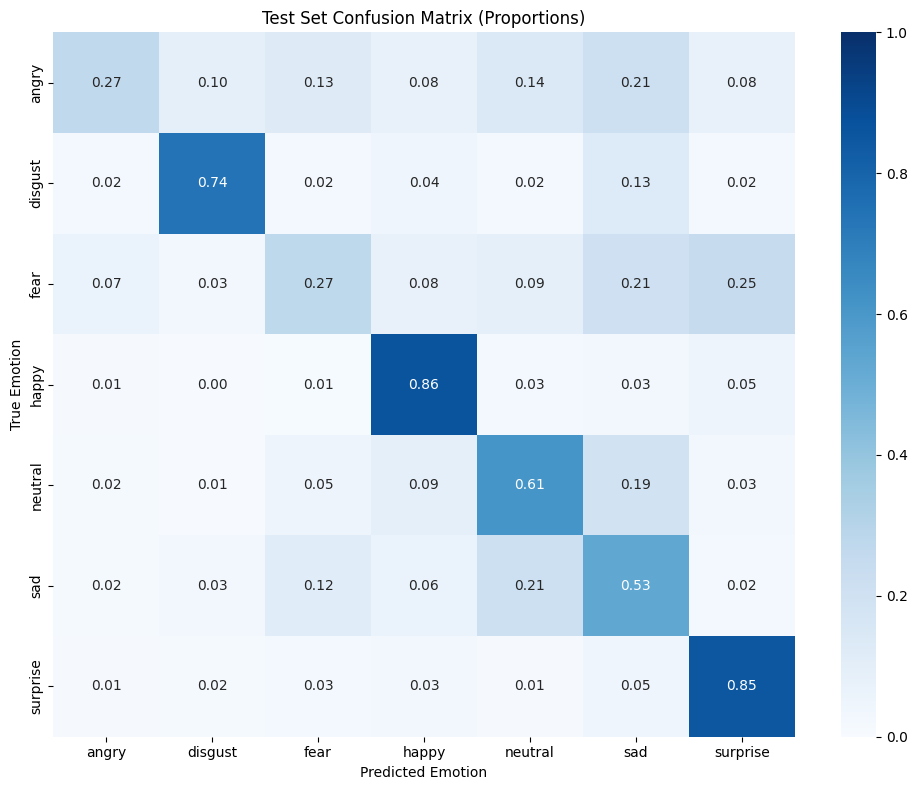

In [ ]:

compiled_model.eval()

all_preds = []
all_targets = []

# Run inference
with torch.inference_mode():
    for inputs, labels in test_loader:
        outputs = compiled_model(inputs)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

# Classification Report to show Precision, Recall, and F1-Score for each of the 7 emotions
print("\nClassification Report:")
print(classification_report(all_targets, all_preds, target_names=label_names))

# Calculate the raw confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Row-normalized confusion matrix: proportions within each true class
cm_prop = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_prop,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=label_names,
    yticklabels=label_names,
    vmin=0,
    vmax=1
)

plt.title("Test Set Confusion Matrix (Proportions)")
plt.xlabel("Predicted Emotion")
plt.ylabel("True Emotion")
plt.tight_layout()
plt.show()

## Gender Bias Analysis

To evaluate potential gender bias in the models, we conducted three types of tests to uncover
representational/stereotypical and confidence bias. First, we perform a chi-squared test to determine
if the overall gap in classification accuracy between male and female is statistically signification. We
then examine which emotions are more or less misclassified by gender, computing true positive rates
(TPR) and false positive rates (FPR) and comparing between genders. Finally, we assess the model's
underlying confidence by looking at the softmax outputs before binary classification, along with a
confusion matrix separated by gender.

In [ ]:
CHECKPOINT_PATH = "/content/drive/MyDrive/fer-project/fer2013_processed/best_model_cnn_aug.pth"
RESULTS_CSV     = "/content/drive/MyDrive/fer-project/fer2013_processed/MODEL_bias_results.csv"
refined_base_dir = "/content/drive/MyDrive/fer-project/fer2013_refined"

image_files = []
labels = []
ADULT_LABELS = {"male_adult", "female_adult"}

for root, _, files in os.walk(refined_base_dir):
    folder_name = os.path.basename(root)

    # Skip 'baby' and the root dir itself
    if folder_name not in ADULT_LABELS:
        continue

    for f in files:
        if f.lower().endswith((".png", ".jpg", ".jpeg")):
            # Extract emotion from filename (e.g. "happy_Training_123.jpg" -> "happy")
            emotion_label = f.split('_')[0]

            image_files.append(os.path.join(root, f))
            labels.append(emotion_label)

label_names = sorted(list(set(labels)))
label_to_idx = {label: i for i, label in enumerate(label_names)}
idx_to_label = {i: label for label, i in label_to_idx.items()}

print("Classes:", label_names)
print("Total refined images:", len(image_files))

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Total refined images: 17166


In [ ]:

_, temp_files, _, temp_labels = train_test_split(
    image_files, labels, test_size=0.20, stratify=labels, random_state=SEED)
_, test_files, _, _ = train_test_split(
    temp_files, temp_labels, test_size=0.5, stratify=temp_labels, random_state=SEED)
print(f'Test set size: {len(test_files)}')


val_transform = transforms.Compose([
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.5,), std=(0.5,)),
])
BATCH_SIZE   = 64
loader_kwargs = dict(num_workers=2, pin_memory=True) if torch.cuda.is_available() else {}

Test set size: 1717


In [ ]:
class BiasTestDataset(Dataset):
    def __init__(self, filepaths, transform=None):
        self.filepaths = filepaths
        self.transform = transform

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        path   = self.filepaths[idx]
        img    = Image.open(path).convert('L')   # grayscale -- matches training
        if self.transform:
            img = self.transform(img)
        gender  = os.path.basename(os.path.dirname(path))
        emotion = os.path.basename(path).split('_')[0]
        return img, label_to_idx[emotion], gender

bias_test_dataset = BiasTestDataset(test_files, transform=val_transform)
bias_test_loader  = DataLoader(bias_test_dataset, batch_size=BATCH_SIZE,
                               shuffle=False, **loader_kwargs)

In [ ]:
model = BaselineCNN(num_classes=len(label_names)).to(device)
model = torch.compile(model)
state_dict = torch.load(CHECKPOINT_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()
print(f'Loaded: {CHECKPOINT_PATH}')

Loaded: /content/drive/MyDrive/fer-project/fer2013_processed/best_model_cnn_aug.pth


In [ ]:
#Forward pass to predict classes
def evaluate_bias(model, loader):
    rows = []
    with torch.no_grad():
        for x, y_emotion, genders in tqdm(loader, desc='Forward pass'):
            x     = x.to(device, non_blocking=True)
            probs = F.softmax(model(x), dim=1)
            confs, preds = probs.max(dim=1)
            for t, p, c, g in zip(y_emotion.numpy(),
                                   preds.cpu().numpy(),
                                   confs.cpu().numpy(),
                                   genders):
                rows.append((int(t), int(p), float(c), g))
    df = pd.DataFrame(rows, columns=['true_idx', 'pred_idx', 'confidence', 'gender'])
    df['true_emotion'] = df['true_idx'].map(idx_to_label)
    df['pred_emotion'] = df['pred_idx'].map(idx_to_label)
    df['is_correct']   = df['true_emotion'] == df['pred_emotion']
    return df

df_results = evaluate_bias(model, bias_test_loader)
df_results.to_csv(RESULTS_CSV, index=False)
print(f'{len(df_results)} predictions saved -> {RESULTS_CSV}')
print(df_results['gender'].value_counts())
print(f'Overall accuracy: {df_results["is_correct"].mean():.4f}')

Forward pass: 100%|██████████| 27/27 [08:15<00:00, 18.34s/it]

1717 predictions saved -> /content/drive/MyDrive/fer-project/fer2013_processed/MODEL_bias_results.csv
gender
male_adult      1118
female_adult     599
Name: count, dtype: int64
Overall accuracy: 0.5807


### Analysis 1: Overall accuracy bias

Does overall accuracy differ between male and female faces? Reports per-class
F1 per gender, Wilson 95% CIs on overall accuracy, and a chi-square test on
the accuracy gap (p < 0.05 means the gap is unlikely to be noise).


In [ ]:

print("Analysis 1: Overall accuracy bias")


genders = sorted(df_results["gender"].unique())


def wilson_ci(p, n, z=1.96):
    # 95% Wilson score CI for a binomial proportion
    denom  = 1 + z * z / n
    center = (p + z * z / (2 * n)) / denom
    margin = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / denom
    return center - margin, center + margin


for g in genders:
    df_g = df_results[df_results["gender"] == g]
    n    = len(df_g)
    acc  = df_g["is_correct"].mean()
    lo, hi = wilson_ci(acc, n)
    print(f"\n--- {g}  (n={n}) ---")
    print(f"Overall accuracy: {acc:.4f}  (95% CI: [{lo:.4f}, {hi:.4f}])")
    print(classification_report(
        df_g["true_emotion"], df_g["pred_emotion"],
        labels=label_names, zero_division=0, digits=3,
    ))

contingency = pd.crosstab(df_results["gender"], df_results["is_correct"])
chi2, p_value, _, _ = chi2_contingency(contingency)
print("\n--- Statistical significance of the accuracy gap ---")
print(contingency)
print(f"chi^2 = {chi2:.3f},  p = {p_value:.4f}")
if p_value < 0.05:
  print("p < 0.05  =>  the gap is unlikely to be noise")
else:
  print("p > 0.05 => the gap may be noise")


Analysis 1: Overall accuracy bias

--- female_adult  (n=599) ---
Overall accuracy: 0.5292  (95% CI: [0.4892, 0.5689])
              precision    recall  f1-score   support

       angry      0.447     0.425     0.436        40
     disgust      0.067     0.500     0.118         4
        fear      0.686     0.210     0.321       229
       happy      0.804     0.820     0.812       100
     neutral      0.299     0.548     0.387        42
         sad      0.220     0.558     0.316        43
    surprise      0.699     0.858     0.771       141

    accuracy                          0.529       599
   macro avg      0.460     0.560     0.451       599
weighted avg      0.628     0.529     0.519       599


--- male_adult  (n=1118) ---
Overall accuracy: 0.6082  (95% CI: [0.5793, 0.6364])
              precision    recall  f1-score   support

       angry      0.673     0.424     0.521       238
     disgust      0.400     0.696     0.508        23
        fear      0.389     0.146     0

### Analysis 2: per-emotion TPR + FPR

Does the model over-predict specific emotions for one gender (the "angry men
/ happy women" stereotype)? Reports True Positive Rate and False Positive Rate per
emotion per gender, with male - female deltas.


In [ ]:
print("Analysis 2: per-emotion TPR + FPR")



def per_class_rates(df_subset, classes):
    cm = confusion_matrix(
        df_subset["true_emotion"], df_subset["pred_emotion"], labels=classes
    )
    fp = cm.sum(axis=0) - np.diag(cm)
    fn = cm.sum(axis=1) - np.diag(cm)
    tp = np.diag(cm)
    tn = cm.sum() - (fp + fn + tp)
    eps = 1e-9
    return pd.DataFrame({
        "TPR":     tp / (tp + fn + eps),   # true positive rate for this emotion
        "FPR":     fp / (fp + tn + eps),   # false positive rate for this emotion
        "support": tp + fn,
    }, index=classes)


rates = {g: per_class_rates(df_results[df_results["gender"] == g], label_names)
         for g in genders}
combined = pd.concat(rates, axis=1)
print("\nPer-emotion TPR / FPR by gender:")
print(combined.round(4))

if {"male_adult", "female_adult"}.issubset(genders):
    delta = pd.DataFrame({
        "TPR (M - F)": rates["male_adult"]["TPR"] - rates["female_adult"]["TPR"],
        "FPR (M - F)": rates["male_adult"]["FPR"] - rates["female_adult"]["FPR"],
    })
    print("\nGender gaps (positive = higher rate on men):")
    print(delta.round(4))

Analysis 2: per-emotion TPR + FPR

Per-emotion TPR / FPR by gender:
         female_adult                 male_adult                
                  TPR     FPR support        TPR     FPR support
angry          0.4250  0.0376      40     0.4244  0.0557     238
disgust        0.5000  0.0471       4     0.6957  0.0219      23
fear           0.2096  0.0595     229     0.1458  0.0339     144
happy          0.8200  0.0401     100     0.8798  0.0385     208
neutral        0.5476  0.0969      42     0.7143  0.1054     245
sad            0.5581  0.1529      43     0.6851  0.1782     181
surprise       0.8582  0.1135     141     0.7595  0.0366      79

Gender gaps (positive = higher rate on men):
          TPR (M - F)  FPR (M - F)
angry         -0.0006       0.0181
disgust        0.1957      -0.0251
fear          -0.0638      -0.0256
happy          0.0598      -0.0016
neutral        0.1667       0.0084
sad            0.1269       0.0254
surprise      -0.0987      -0.0770


In [ ]:

print('Statistical significance of TPR / FPR gaps')


rows = []
for emotion in label_names:
    # TPR significance: correct vs missed, among true positives only
    for gender in ['male_adult', 'female_adult']:
        df_g = df_results[df_results['gender'] == gender]
        df_pos = df_g[df_g['true_emotion'] == emotion]   # actual positives
        tp = (df_pos['pred_emotion'] == emotion).sum()
        fn = (df_pos['pred_emotion'] != emotion).sum()
        if gender == 'male_adult':
            tp_m, fn_m = tp, fn
        else:
            tp_f, fn_f = tp, fn

    # FPR significance: false alarm vs correct rejection, among true negatives
    for gender in ['male_adult', 'female_adult']:
        df_g = df_results[df_results['gender'] == gender]
        df_neg = df_g[df_g['true_emotion'] != emotion]   # actual negatives
        fp = (df_neg['pred_emotion'] == emotion).sum()
        tn = (df_neg['pred_emotion'] != emotion).sum()
        if gender == 'male_adult':
            fp_m, tn_m = fp, tn
        else:
            fp_f, tn_f = fp, tn

    # Chi-square or Fisher's exact (use Fisher if any cell < 5)
    tpr_table = [[tp_m, fn_m], [tp_f, fn_f]]
    fpr_table = [[fp_m, tn_m], [fp_f, tn_f]]

    min_tpr = min(tp_m, fn_m, tp_f, fn_f)
    min_fpr = min(fp_m, tn_m, fp_f, tn_f)

    if min_tpr < 5:
        _, p_tpr = fisher_exact(tpr_table)
        tpr_test = 'Fisher'
    else:
        _, p_tpr, _, _ = chi2_contingency(tpr_table)
        tpr_test = 'Chi2'

    if min_fpr < 5:
        _, p_fpr = fisher_exact(fpr_table)
        fpr_test = 'Fisher'
    else:
        _, p_fpr, _, _ = chi2_contingency(fpr_table)
        fpr_test = 'Chi2'

    sig_tpr = '***' if p_tpr < 0.001 else ('**' if p_tpr < 0.01 else ('*' if p_tpr < 0.05 else 'ns'))
    sig_fpr = '***' if p_fpr < 0.001 else ('**' if p_fpr < 0.01 else ('*' if p_fpr < 0.05 else 'ns'))

    rows.append({
        'emotion':   emotion,
        'TPR gap (M-F)': round(rates['male_adult']['TPR'][emotion] - rates['female_adult']['TPR'][emotion], 4),
        'p_TPR':     round(p_tpr, 4),
        'TPR sig':   f'{sig_tpr} ({tpr_test})',
        'FPR gap (M-F)': round(rates['male_adult']['FPR'][emotion] - rates['female_adult']['FPR'][emotion], 4),
        'p_FPR':     round(p_fpr, 4),
        'FPR sig':   f'{sig_fpr} ({fpr_test})',
    })

sig_df = pd.DataFrame(rows).set_index('emotion')
print(sig_df.to_string())
print('\n* p<0.05  ** p<0.01  *** p<0.001  ns = not significant')

Statistical significance of TPR / FPR gaps
          TPR gap (M-F)   p_TPR      TPR sig  FPR gap (M-F)   p_FPR     FPR sig
emotion                                                                        
angry           -0.0006  1.0000    ns (Chi2)         0.0181  0.1524   ns (Chi2)
disgust          0.1957  0.5815  ns (Fisher)        -0.0251  0.0067   ** (Chi2)
fear            -0.0638  0.1593    ns (Chi2)        -0.0256  0.0500    * (Chi2)
happy            0.0598  0.2140    ns (Chi2)        -0.0016  0.9950   ns (Chi2)
neutral          0.1667  0.0480     * (Chi2)         0.0084  0.6714   ns (Chi2)
sad              0.1269  0.1611    ns (Chi2)         0.0254  0.2329   ns (Chi2)
surprise        -0.0987  0.0981    ns (Chi2)        -0.0770  0.0000  *** (Chi2)

* p<0.05  ** p<0.01  *** p<0.001  ns = not significant


### Analysis 3 - Confidence bias

Does the model produce systematically lower-confidence predictions on one
gender (suggesting noisier ground-truth labels for that demographic)?
Includes per-emotion confidence comparison and side-by-side normalised
confusion matrices.


Analysis 3: Confidence Bias

Confidence by gender x correctness:
                           mean  median  count
gender       is_correct                       
female_adult False       0.4830  0.4303    282
             True        0.7220  0.7799    317
male_adult   False       0.4310  0.3771    438
             True        0.6257  0.5747    680

Mean confidence per true emotion x gender:
gender        female_adult  male_adult
true_emotion                          
angry               0.5047      0.4353
disgust             0.5912      0.6531
fear                0.4852      0.4563
happy               0.8043      0.8042
neutral             0.5049      0.5252
sad                 0.4558      0.4293
surprise            0.7813      0.7122


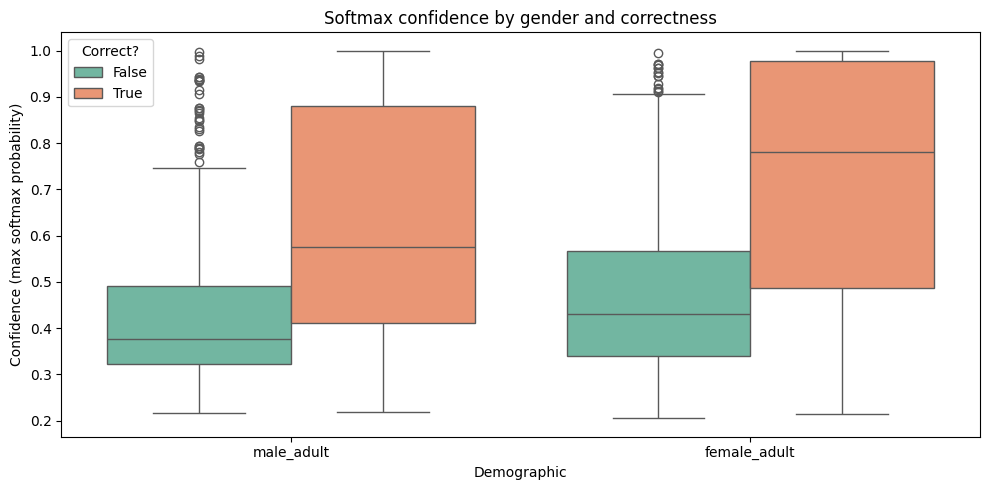

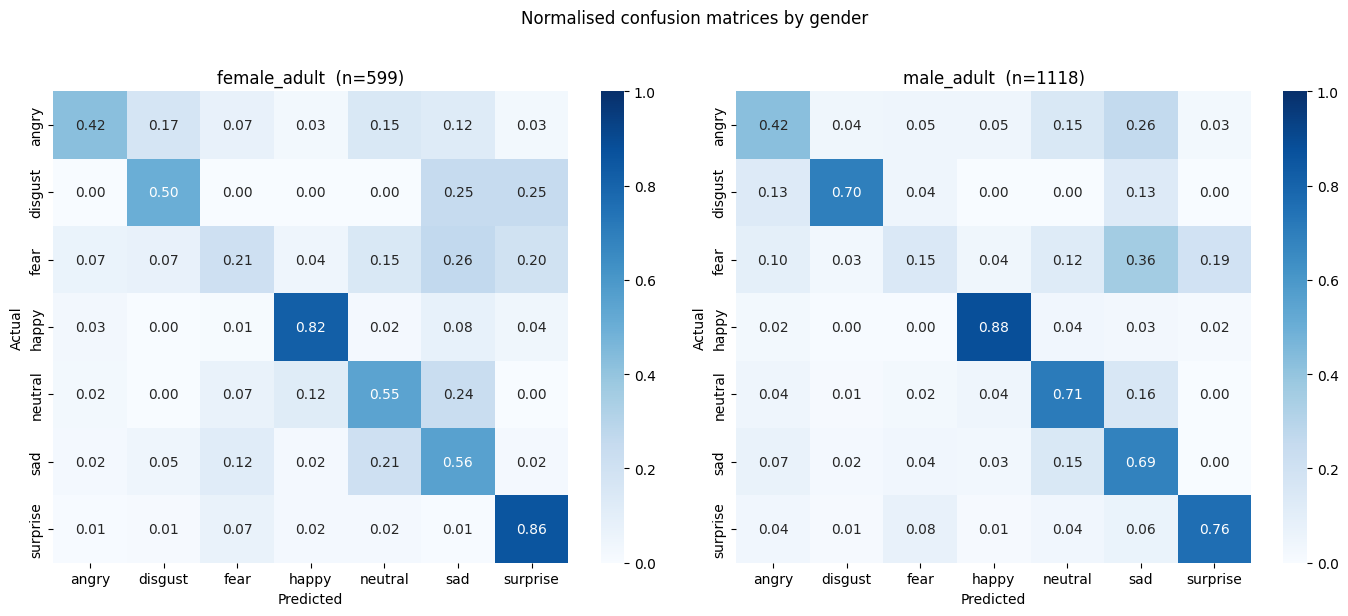

In [ ]:
print("Analysis 3: Confidence Bias")

conf_summary = (df_results
                .groupby(["gender", "is_correct"])["confidence"]
                .agg(["mean", "median", "count"])
                .round(4))
print("\nConfidence by gender x correctness:")
print(conf_summary)

per_emotion_conf = (df_results
                    .groupby(["true_emotion", "gender"])["confidence"]
                    .mean()
                    .unstack("gender")
                    .round(4))
print("\nMean confidence per true emotion x gender:")
print(per_emotion_conf)

# Confidence box plots by gender
plt.figure(figsize=(10, 5))
sns.boxplot(data=df_results, x="gender", y="confidence",
            hue="is_correct", palette="Set2")
plt.title("Softmax confidence by gender and correctness")
plt.xlabel("Demographic")
plt.ylabel("Confidence (max softmax probability)")
plt.legend(title="Correct?")
plt.tight_layout()
plt.show()

# Confusion matrix by gender
fig, axes = plt.subplots(1, len(genders), figsize=(7 * len(genders), 6))
if len(genders) == 1:
    axes = [axes]
for ax, g in zip(axes, genders):
    df_g = df_results[df_results["gender"] == g]
    cm   = confusion_matrix(df_g["true_emotion"], df_g["pred_emotion"],
                            labels=label_names)
    cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)
    sns.heatmap(cm_norm, annot=True, fmt=".2f",
                xticklabels=label_names, yticklabels=label_names,
                cmap="Blues", ax=ax, vmin=0, vmax=1)
    ax.set_title(f"{g}  (n={len(df_g)})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.suptitle("Normalised confusion matrices by gender", y=1.02)
plt.tight_layout()
plt.show()
